# Cross-Asset Stress Diagnostics -- June 5, 2026

**A quantitative diagnostic of correlation regime change across equities, metals, energy and crypto, in the context of the AI-bubble thesis articulated by M. Burry (Scion Asset Management, May 2026) and the broad sell-off flagged the same day by Thami Kabbaj (TKL Trading School).**

---

## Triggering observation

On Friday June 5, 2026, **Thami Kabbaj** -- *agrégé d'économie* (Paris-II Assas), Magistère Banque-Finance, ex-Eurex trader, FSA Derivatives / Series 7, graduate of the Society of Technical Analysts (London), founder of TKL Trading School (Dubai), 450,000+ YouTube subscribers, ~80M cumulative video views, author of multiple finance best-sellers -- published a video titled *Vendredi noir : tout s'effondre en Bourse?* flagging an apparently coordinated decline in the Nasdaq 100, S&P 500, gold, silver, oil and large-cap stocks. The credentials and audience of the source matter: this is a trained technical analyst with an international audience, not a generic doom-and-gloom clip.

This notebook tests, formally, whether the move carries the statistical signature of a *forced-liquidation / margin-call* regime, as opposed to an idiosyncratic asset-class move, and cross-references the findings with the well-known short positions disclosed by Burry's Scion Asset Management.

## Abstract

Using daily adjusted-close data from Yahoo Finance over a 400-day window, we compute:

1. **Pairwise sample correlations** of log returns (Pearson and Spearman) on three windows: 7d / 30d / 180d, with proper handling of overlapping data per pair (no global drop-na that would bias the panel).
2. **The PCA absorption ratio** (Kritzman, Li, Page & Rigobon, 2010) -- the share of total variance explained by the first principal component, a standard systemic risk index.
3. **The average pairwise correlation index** with bootstrap 95% confidence intervals.
4. **The cross-sectional return dispersion** (Pukthuanthong & Roll, 2009).
5. **Forbes-Rigobon (2002) heteroskedasticity-adjusted correlation** to control for the volatility-inflation bias of vanilla Pearson correlation in high-vol regimes.
6. The gold-versus-equities pairwise correlation as a *flight-to-quality* breakage indicator.

We cross-reference these with the bearish thesis publicly articulated by Michael Burry in May 2026 (Scion's expanded put positions on PLTR, NVDA, ORCL, SMH, QQQ; January 2027 expiries; Shiller PE > 40).

## Methodology disclaimer

- All data are Yahoo Finance daily **adjusted closes** (`auto_adjust=True` in `yfinance`); splits and dividends are pre-adjusted. Cash futures (`GC=F`, `SI=F`, `CL=F`, `BZ=F`) are continuous front-month series provided by Yahoo and may exhibit small discontinuities at roll dates.
- Returns are **log returns** ($r_t = \ln(P_t / P_{t-1})$).
- Trading-day alignment: cryptocurrencies (BTC) trade on weekends while equities do not; we restrict the joint panel used for cross-asset measures to **U.S. trading days**.
- This is an *ex-post* diagnostic and **not investment advice**. Statistical significance of correlation breaks under non-stationary, non-Gaussian financial returns should be interpreted with caution (bootstrap CIs are i.i.d.-resampled and may underestimate true uncertainty in regime-shift contexts).


## 1. Environment and data ingestion

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from scipy import stats

# --- Notebook configuration ---
OUT_DIR = Path('./data')
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'csv').mkdir(exist_ok=True)
(OUT_DIR / 'plots').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

ANALYSIS_DATE = datetime.now().strftime('%Y-%m-%d')
print(f'Analysis date: {ANALYSIS_DATE}')
print(f'numpy={np.__version__}  pandas={pd.__version__}  yfinance={yf.__version__}')
print(f'Outputs directory: {OUT_DIR.resolve()}')

Analysis date: 2026-06-05
numpy=1.26.4  pandas=2.1.4  yfinance=1.1.0
Outputs directory: D:\dev\projects\labs\202606\data


In [2]:
# --- Asset universe (Yahoo Finance symbology) ---
TICKERS = {
    # Precious metals (continuous front-month futures)
    'XAU':   'GC=F',
    'XAG':   'SI=F',
    # Energy (continuous front-month futures)
    'WTI':   'CL=F',
    'BRENT': 'BZ=F',
    # US equity indices
    'NDX':   '^NDX',     # Nasdaq 100
    'SPX':   '^GSPC',    # S&P 500
    'DJI':   '^DJI',     # Dow Jones Industrial
    # Volatility and dollar
    'VIX':   '^VIX',     # CBOE volatility index
    'DXY':   'DX-Y.NYB', # US dollar index
    # Cryptocurrency
    'BTC':   'BTC-USD',
    # Mega-cap tech
    'MSFT':  'MSFT',
    'AAPL':  'AAPL',
    'META':  'META',
    'NFLX':  'NFLX',
    # AI / semiconductors (core of Burry's thesis)
    'NVDA':  'NVDA',
    'AVGO':  'AVGO',
    'PLTR':  'PLTR',
    'ORCL':  'ORCL',
    'SMH':   'SMH',      # iShares Semiconductor ETF
    'QQQ':   'QQQ',      # Invesco QQQ Trust
    # Long-duration bonds (flight-to-quality alt.)
    'TLT':   'TLT',      # 20+ year Treasury ETF
}

# Asset groupings for downstream analysis
EQUITIES     = ['NDX', 'SPX', 'DJI', 'MSFT', 'AAPL', 'META', 'NFLX', 'NVDA', 'AVGO', 'PLTR', 'ORCL', 'SMH', 'QQQ']
METALS       = ['XAU', 'XAG']
ENERGY       = ['WTI', 'BRENT']
CRYPTO       = ['BTC']
BONDS        = ['TLT']
DOLLAR_VOL   = ['DXY', 'VIX']
BURRY_SHORTS = ['PLTR', 'NVDA', 'SMH', 'QQQ', 'ORCL']

print(f'Universe size: {len(TICKERS)}')
print(f'  Equities ({len(EQUITIES)}): {EQUITIES}')
print(f'  Metals ({len(METALS)}): {METALS}')
print(f'  Energy ({len(ENERGY)}): {ENERGY}')
print(f'  Crypto ({len(CRYPTO)}): {CRYPTO}')
print(f'  Bonds ({len(BONDS)}): {BONDS}')
print(f'  Dollar/Vol ({len(DOLLAR_VOL)}): {DOLLAR_VOL}')
print(f'  Burry-disclosed shorts ({len(BURRY_SHORTS)}): {BURRY_SHORTS}')

Universe size: 21
  Equities (13): ['NDX', 'SPX', 'DJI', 'MSFT', 'AAPL', 'META', 'NFLX', 'NVDA', 'AVGO', 'PLTR', 'ORCL', 'SMH', 'QQQ']
  Metals (2): ['XAU', 'XAG']
  Energy (2): ['WTI', 'BRENT']
  Crypto (1): ['BTC']
  Bonds (1): ['TLT']
  Dollar/Vol (2): ['DXY', 'VIX']
  Burry-disclosed shorts (5): ['PLTR', 'NVDA', 'SMH', 'QQQ', 'ORCL']


In [3]:
# --- Fetch routine with disk cache ---
LOOKBACK_DAYS = 400
END = datetime.now()
START = END - timedelta(days=LOOKBACK_DAYS)
CACHE_TTL_SECONDS = 3600  # 1h

def fetch_ticker(label: str, ticker: str) -> pd.DataFrame | None:
    cache = OUT_DIR / 'csv' / f'{label}.csv'
    if cache.exists() and (datetime.now().timestamp() - cache.stat().st_mtime) < CACHE_TTL_SECONDS:
        df = pd.read_csv(cache, index_col=0, parse_dates=True)
        return df
    try:
        raw = yf.download(
            ticker, start=START, end=END + timedelta(days=1),
            progress=False, auto_adjust=True, group_by='ticker',
        )
        if raw.empty:
            return None
        # Flatten multi-index when yfinance returns one
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = [c[-1] if c[-1] else c[0] for c in raw.columns]
        # Keep only the columns we use
        keep = [c for c in ['Open', 'High', 'Low', 'Close', 'Volume'] if c in raw.columns]
        raw = raw[keep]
        raw.to_csv(cache)
        return raw
    except Exception as e:
        print(f'  ERROR fetching {label} ({ticker}): {e}')
        return None

data = {}
for label, ticker in TICKERS.items():
    df = fetch_ticker(label, ticker)
    if df is None or df.empty:
        print(f'  {label:6s} ({ticker:11s}): NO DATA')
        continue
    data[label] = df
    print(f'  {label:6s} ({ticker:11s}): {len(df):4d} bars  '
          f'[{df.index[0].date()} -> {df.index[-1].date()}]  last_close={df["Close"].iloc[-1]:.2f}')

print(f'\nFetched {len(data)} / {len(TICKERS)} tickers')
print(f'Cache directory: {(OUT_DIR / "csv").resolve()}')

  XAU    (GC=F       ):  277 bars  [2025-05-01 -> 2026-06-05]  last_close=4353.90


  XAG    (SI=F       ):  277 bars  [2025-05-01 -> 2026-06-05]  last_close=68.00


  WTI    (CL=F       ):  277 bars  [2025-05-01 -> 2026-06-05]  last_close=90.25


  BRENT  (BZ=F       ):  277 bars  [2025-05-01 -> 2026-06-05]  last_close=92.87


  NDX    (^NDX       ):  276 bars  [2025-05-01 -> 2026-06-05]  last_close=28957.60


...

  PLTR   (PLTR       ):  276 bars  [2025-05-01 -> 2026-06-05]  last_close=135.53


  ORCL   (ORCL       ):  276 bars  [2025-05-01 -> 2026-06-05]  last_close=213.68


  SMH    (SMH        ):  276 bars  [2025-05-01 -> 2026-06-05]  last_close=569.69


  QQQ    (QQQ        ):  276 bars  [2025-05-01 -> 2026-06-05]  last_close=705.06


  TLT    (TLT        ):  276 bars  [2025-05-01 -> 2026-06-05]  last_close=85.06

Fetched 21 / 21 tickers
Cache directory: D:\dev\projects\labs\202606\data\csv


In [4]:
# --- Build joint price panel + log return panel ---
# We use Close (which is already split/dividend-adjusted via auto_adjust=True)
px = pd.DataFrame({k: v['Close'] for k, v in data.items()}).sort_index()

# Trading-day alignment: restrict to U.S. trading days (where SPX has a quote)
# This avoids the BTC-weekend bias in cross-asset correlations.
if 'SPX' in px.columns:
    spx_days = px['SPX'].dropna().index
    px_eq = px.reindex(spx_days)
else:
    px_eq = px

ret = np.log(px_eq / px_eq.shift(1)).dropna(how='all')

print(f'Price panel: {px_eq.shape}  ({px_eq.index[0].date()} -> {px_eq.index[-1].date()})')
print(f'Log-return panel: {ret.shape}')
print(f'Last 5 observations (closes):')
print(px_eq.tail(5).round(2))

Price panel: (276, 21)  (2025-05-01 -> 2026-06-05)
Log-return panel: (275, 21)
Last 5 observations (closes):
               XAU    XAG    WTI  BRENT       NDX      SPX       DJI    VIX  \
Date                                                                          
2026-06-01  4475.2  75.01  92.16  94.98  30513.86  7599.96  51078.88  16.05   
2026-06-02  4489.1  75.31  93.76  96.00  30660.60  7609.78  51307.79  15.77   
2026-06-03  4436.7  73.48  96.02  97.81  30571.24  7553.68  50687.07  16.06   
2026-06-04  4475.8  73.78  93.04  95.03  30407.81  7584.31  51561.93  15.40   
2026-06-05  4353.9  68.00  90.25  92.87  28957.60  7383.74  50866.78  21.51   

               DXY       BTC  ...    AAPL    META   NFLX    NVDA    AVGO  \
Date                          ...                                          
2026-06-01   99.20  71319.77  ...  306.31  600.47  85.85  224.10  459.97   
2026-06-02   99.22  66703.66  ...  315.20  597.63  83.33  222.56  481.57   
2026-06-03   99.53  64014.37  ...

## 2. Snapshot: per-asset performance

In [5]:
def perf_table(px: pd.DataFrame, horizons_days: dict) -> pd.DataFrame:
    rows = []
    last_date = px.index[-1]
    for col in px.columns:
        s = px[col].dropna()
        row = {'asset': col, 'last_date': s.index[-1].strftime('%Y-%m-%d'),
               'last_close': float(s.iloc[-1])}
        for name, days in horizons_days.items():
            cutoff = last_date - pd.Timedelta(days=days)
            sub = s[s.index >= cutoff]
            if len(sub) < 2:
                row[f'ret_{name}_%'] = np.nan
                row[f'maxdd_{name}_%'] = np.nan
                continue
            row[f'ret_{name}_%'] = float((sub.iloc[-1] / sub.iloc[0] - 1) * 100)
            running_max = sub.cummax()
            running_dd = (sub / running_max - 1) * 100
            row[f'maxdd_{name}_%'] = float(running_dd.min())
        rows.append(row)
    return pd.DataFrame(rows).set_index('asset')

HORIZONS = {'1d': 2, '7d': 7, '30d': 30, '90d': 90, '365d': 365}
perf_df = perf_table(px_eq, HORIZONS)
perf_df_sorted = perf_df.sort_values('ret_7d_%')

print('=' * 90)
print('PERFORMANCE TABLE -- sorted by 7-day return (worst first)')
print('=' * 90)
show_cols = ['last_close', 'ret_1d_%', 'ret_7d_%', 'ret_30d_%', 'ret_90d_%', 'ret_365d_%',
             'maxdd_7d_%', 'maxdd_30d_%']
print(perf_df_sorted[show_cols].to_string(float_format=lambda x: f'{x:>+8.2f}'))
perf_df_sorted.to_csv(OUT_DIR / 'csv' / 'performance_snapshot.csv')
print(f'\nSaved: {(OUT_DIR / "csv" / "performance_snapshot.csv").name}')

PERFORMANCE TABLE -- sorted by 7-day return (worst first)
       last_close  ret_1d_%  ret_7d_%  ret_30d_%  ret_90d_%  ret_365d_%  maxdd_7d_%  maxdd_30d_%
asset                                                                                           
BTC     +61798.98     -3.46    -15.77     -24.11      -9.65      -39.16      -15.77       -24.38
AVGO      +385.73    -19.51    -13.66      -9.33     +11.80      +49.60      -19.90       -19.90
PLTR      +135.53     -4.69    -13.42      +1.30     -13.36      +13.03      -15.64       -15.64
XAG        +68.00     -7.46    -10.08     -11.48     -19.08      +90.52      -10.08       -23.50
MSFT      +416.67     -2.50     -7.46      +0.87      +1.99      -10.20       -9.52        -9.52
META      +593.00     -4.81     -6.25      -3.24      -8.32      -13.11       -6.25        -6.66
ORCL      +213.68     -7.23     -5.36     +10.13     +41.48      +26.11      -13.89       -13.89
SMH       +569.69    -10.69     -4.88      +3.63     +44.46     +127.

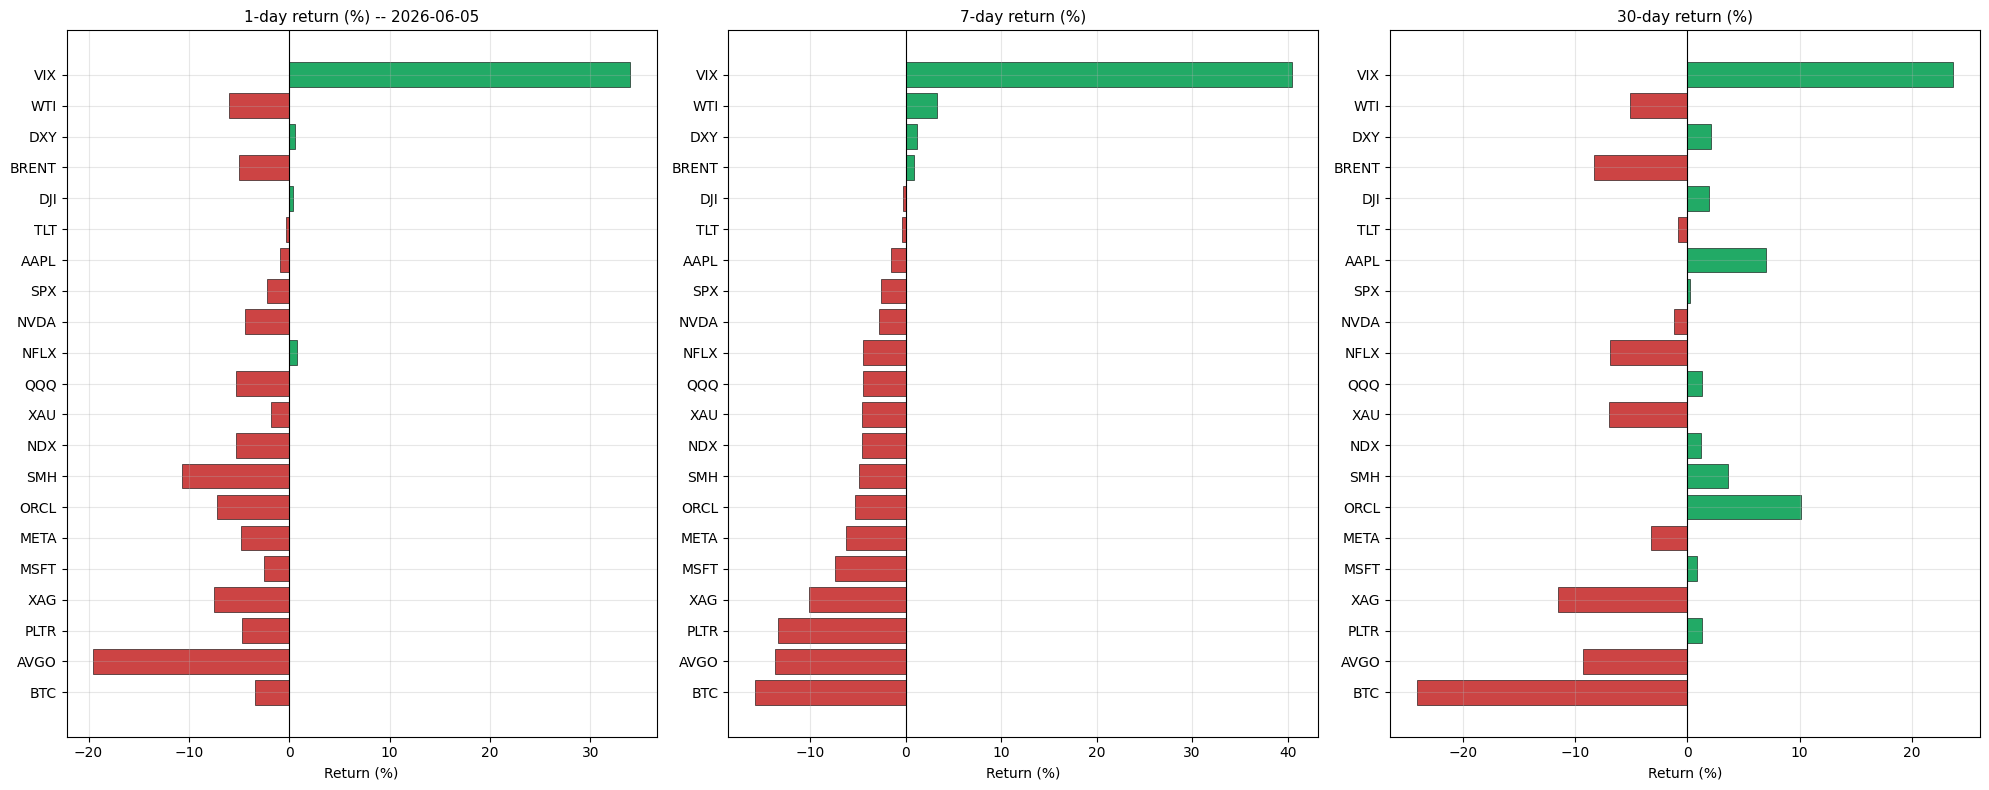

In [6]:
# Visual: horizontal bar chart, sorted by 7-day return
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, col, title in zip(
    axes,
    ['ret_1d_%', 'ret_7d_%', 'ret_30d_%'],
    [f'1-day return (%) -- {ANALYSIS_DATE}',
     '7-day return (%)',
     '30-day return (%)']):
    vals = perf_df_sorted[col]
    colors = ['#cc4444' if v < 0 else '#22aa66' for v in vals]
    ax.barh(vals.index, vals.values, color=colors, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Return (%)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'performance_bars.png', dpi=110, bbox_inches='tight')
plt.show()

## 3. Price evolution (normalized to peak)

Each series is normalized to its 90-day maximum (peak = 100). Distance below 100 visualizes the drawdown from the recent peak.

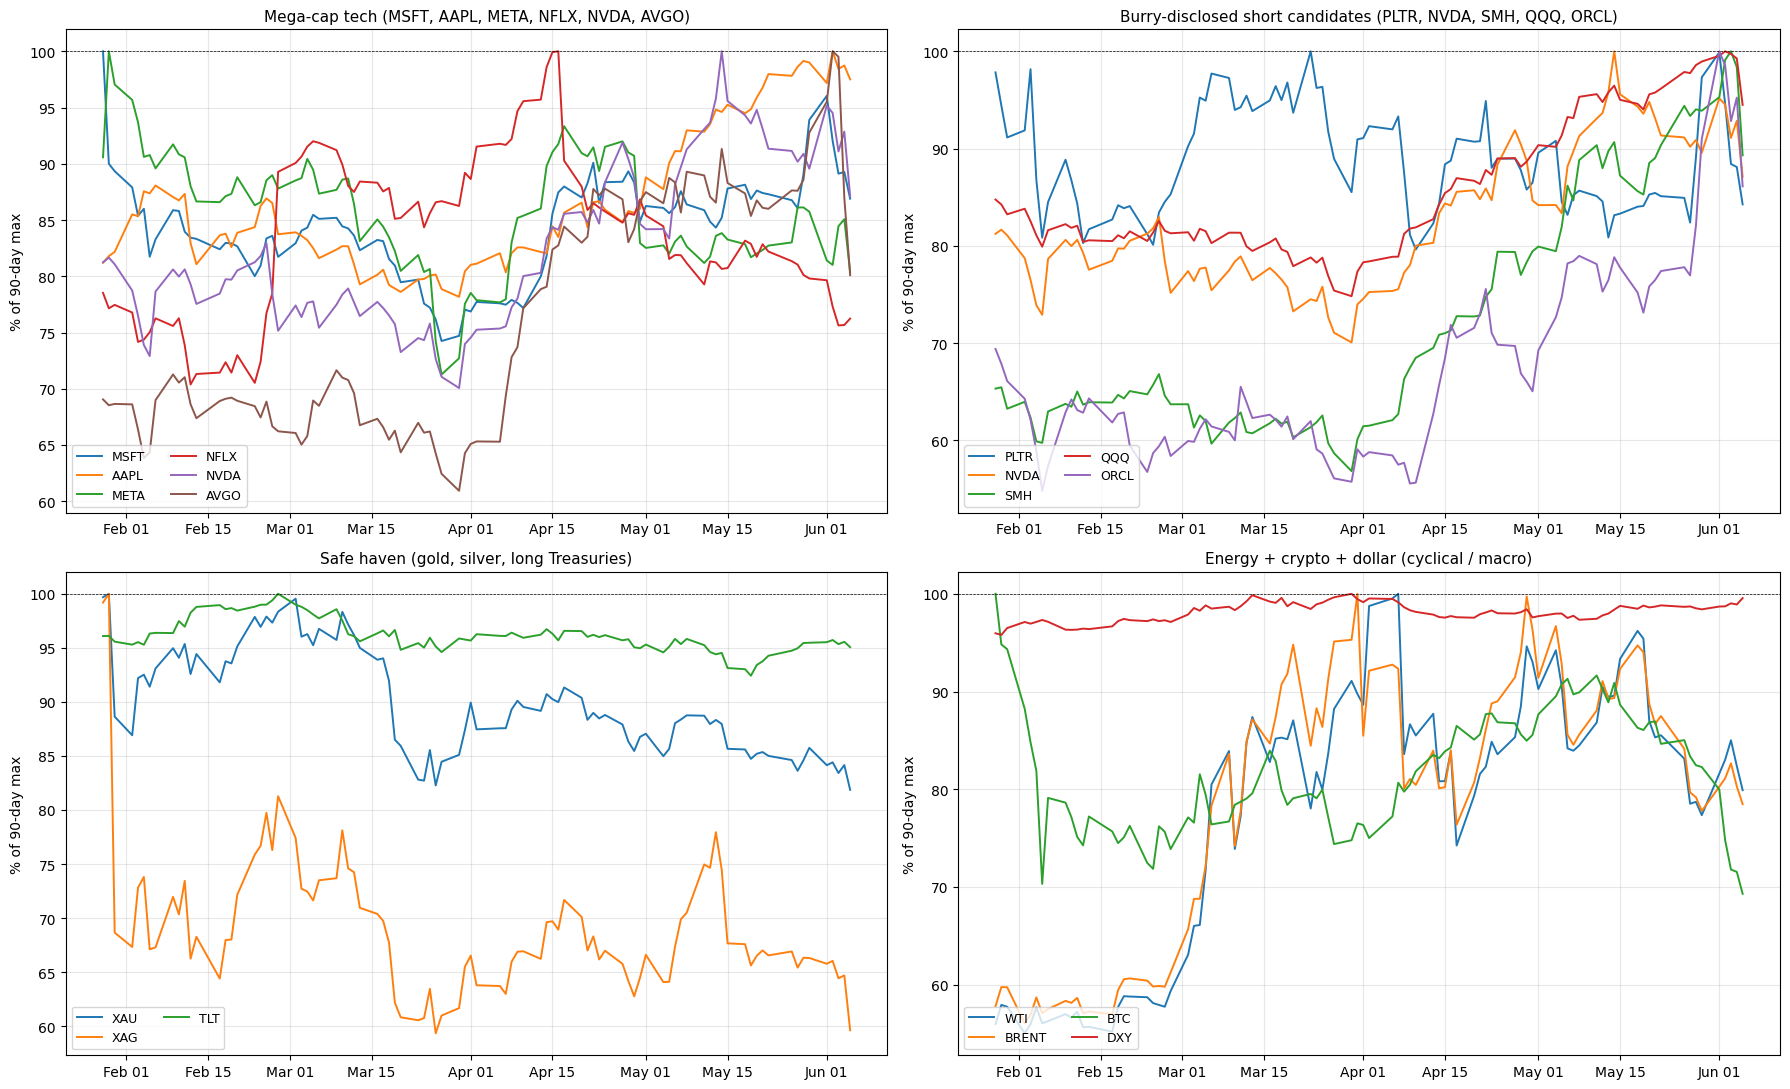

In [7]:
recent = px_eq.iloc[-90:].copy()
norm = recent.divide(recent.max(axis=0)) * 100

groups = [
    ('Mega-cap tech (MSFT, AAPL, META, NFLX, NVDA, AVGO)',
     ['MSFT', 'AAPL', 'META', 'NFLX', 'NVDA', 'AVGO']),
    ('Burry-disclosed short candidates (PLTR, NVDA, SMH, QQQ, ORCL)',
     BURRY_SHORTS),
    ('Safe haven (gold, silver, long Treasuries)',
     METALS + BONDS),
    ('Energy + crypto + dollar (cyclical / macro)',
     ENERGY + CRYPTO + ['DXY']),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
for ax, (title, cols) in zip(axes.flat, groups):
    cols = [c for c in cols if c in norm.columns]
    for c in cols:
        ax.plot(norm.index, norm[c], label=c, lw=1.4)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('% of 90-day max')
    ax.axhline(100, color='black', lw=0.5, linestyle='--')
    ax.legend(loc='lower left', fontsize=9, ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'normalized_prices.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Correlation regime comparison

We compute pairwise correlations of daily log returns using **pairwise overlapping windows** -- each $(i, j)$ cell uses the maximum number of dates for which both series have a valid return, rather than dropping the full panel when any series is missing on a date. This is critical because some series (e.g. crypto fetched on weekends, futures on holidays) would otherwise truncate the panel and bias the estimates.

We report both **Pearson** (linear) and **Spearman** (rank) correlations for robustness.

In [8]:
def pairwise_corr(rets: pd.DataFrame, days: int, method: str = 'pearson') -> tuple[pd.DataFrame, pd.DataFrame]:
    """Pairwise correlation using overlapping data per pair.
    Returns (corr_matrix, count_matrix) where count_matrix[i,j] is the number of joint observations."""
    cutoff = rets.index[-1] - pd.Timedelta(days=days)
    sub = rets[rets.index >= cutoff]
    c = sub.corr(method=method, min_periods=max(3, days // 4))
    n = sub.notna().astype(int).T.dot(sub.notna().astype(int))
    return c, n

corr_180_p, n180 = pairwise_corr(ret, 180, 'pearson')
corr_180_s, _    = pairwise_corr(ret, 180, 'spearman')
corr_30_p, n30   = pairwise_corr(ret, 30, 'pearson')
corr_7_p, n7     = pairwise_corr(ret, 7, 'pearson')

# Use only tickers with sufficient observations across all three windows
min_obs = lambda n: (n > 3).all()
common = [c for c in corr_180_p.columns
          if c in corr_30_p.columns and c in corr_7_p.columns
          and corr_180_p[c].notna().sum() > 5
          and corr_30_p[c].notna().sum() > 5
          and corr_7_p[c].notna().sum() > 3]
print(f'Tickers with sufficient observations across 7d/30d/180d windows: {len(common)}')
print(common)

Tickers with sufficient observations across 7d/30d/180d windows: 21
['XAU', 'XAG', 'WTI', 'BRENT', 'NDX', 'SPX', 'DJI', 'VIX', 'DXY', 'BTC', 'MSFT', 'AAPL', 'META', 'NFLX', 'NVDA', 'AVGO', 'PLTR', 'ORCL', 'SMH', 'QQQ', 'TLT']


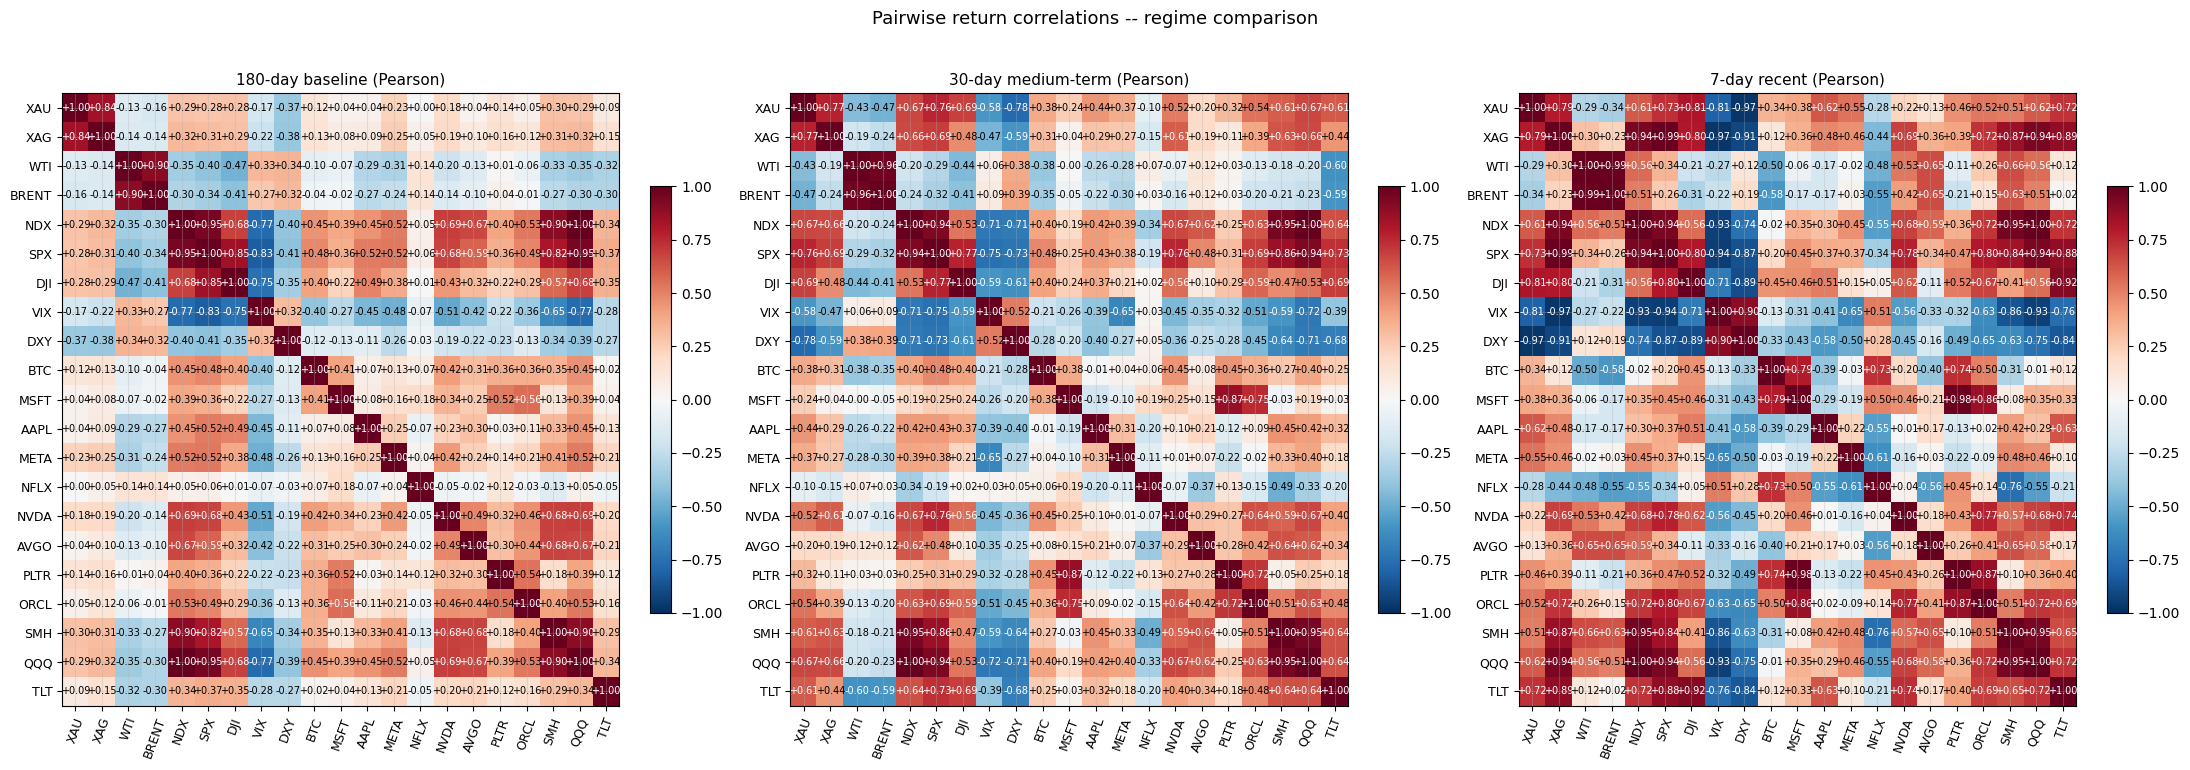

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))
for ax, (mat, title) in zip(axes, [
    (corr_180_p.loc[common, common], '180-day baseline (Pearson)'),
    (corr_30_p.loc[common, common], '30-day medium-term (Pearson)'),
    (corr_7_p.loc[common, common], '7-day recent (Pearson)'),
]):
    im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(common)))
    ax.set_yticks(range(len(common)))
    ax.set_xticklabels(common, rotation=70, fontsize=9)
    ax.set_yticklabels(common, fontsize=9)
    for i in range(len(common)):
        for j in range(len(common)):
            v = mat.iloc[i, j]
            if pd.notna(v):
                color = 'white' if abs(v) > 0.55 else 'black'
                ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=7, color=color)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.035)
plt.suptitle('Pairwise return correlations -- regime comparison',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'correlation_heatmaps.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Systemic stress measures

### 5.1 Average pairwise correlation index (with bootstrap CI)

We compute the average of off-diagonal pairwise Pearson correlations on a rolling window, restricted to the **core risk universe** (equity indices + mega-cap tech + metals + energy + crypto). Higher values indicate compressed dispersion / synchronized moves -- the empirical signature of forced-liquidation regimes (cf. Kritzman et al. 2010; Pukthuanthong & Roll 2009).

Bootstrap 95% confidence intervals are computed by i.i.d. resampling 1000 times within each window.

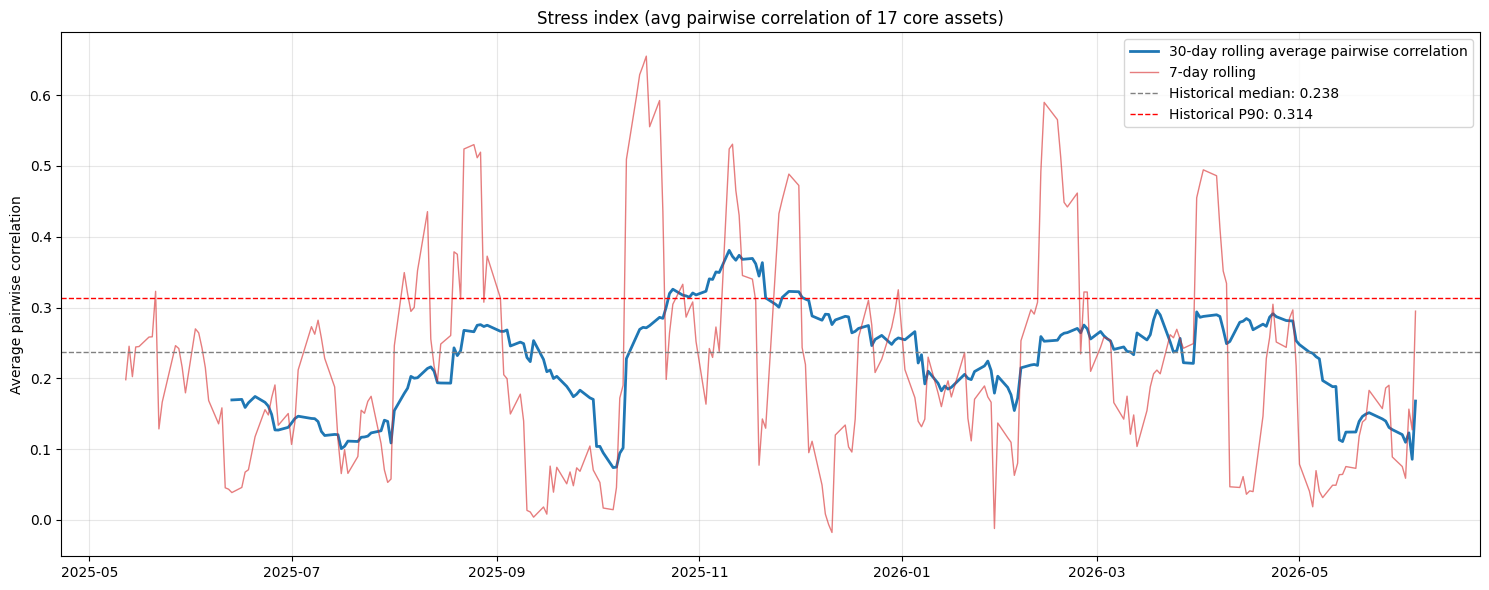


=== Current stress index ===
  Latest 30d  : +0.168   bootstrap 95% CI: [+0.042, +0.307]
  Latest 7d   : +0.295    bootstrap 95% CI: [-0.032, +0.532]
  Historical median   (400d) : +0.238
  Historical P90      (400d) : +0.314
  Z-score of latest 30d vs full distribution : -0.84


In [10]:
CORE = [c for c in ['NDX', 'SPX', 'DJI', 'XAU', 'XAG', 'WTI', 'BRENT', 'BTC',
                     'MSFT', 'AAPL', 'AVGO', 'NVDA', 'META', 'NFLX', 'PLTR', 'ORCL', 'SMH']
        if c in ret.columns]
core_ret = ret[CORE].dropna(how='all')

def avg_pairwise_corr(df: pd.DataFrame) -> float:
    c = df.corr().values
    n = c.shape[0]
    if n < 2:
        return np.nan
    mask = np.triu(np.ones((n, n)), k=1).astype(bool)
    return float(np.nanmean(c[mask]))

def rolling_avg_corr(df: pd.DataFrame, window: int) -> pd.Series:
    out = []
    idx = []
    for i in range(window, len(df) + 1):
        out.append(avg_pairwise_corr(df.iloc[i-window:i]))
        idx.append(df.index[i-1])
    return pd.Series(out, index=idx)

def bootstrap_avg_corr_ci(df: pd.DataFrame, n_boot: int = 1000, seed: int = 42) -> tuple[float, float, float]:
    """Returns (mean, lo_95, hi_95) of avg pairwise corr via i.i.d. bootstrap."""
    rng = np.random.default_rng(seed)
    n = len(df)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boots[b] = avg_pairwise_corr(df.iloc[idx])
    return float(np.mean(boots)), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

stress_30d = rolling_avg_corr(core_ret, 30)
stress_7d  = rolling_avg_corr(core_ret, 7)

# Bootstrap CI on the *current* 30d window
mean_now, lo_now, hi_now = bootstrap_avg_corr_ci(core_ret.iloc[-30:])
mean_7, lo_7, hi_7        = bootstrap_avg_corr_ci(core_ret.iloc[-7:])

# Plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(stress_30d.index, stress_30d.values, lw=2.0, color='C0',
        label='30-day rolling average pairwise correlation')
ax.plot(stress_7d.index, stress_7d.values, lw=1.0, color='C3', alpha=0.6,
        label='7-day rolling')
med = stress_30d.median()
p90 = stress_30d.quantile(0.9)
ax.axhline(med, color='gray', linestyle='--', lw=1, label=f'Historical median: {med:.3f}')
ax.axhline(p90, color='red', linestyle='--', lw=1, label=f'Historical P90: {p90:.3f}')
ax.set_title(f'Stress index (avg pairwise correlation of {len(CORE)} core assets)', fontsize=12)
ax.set_ylabel('Average pairwise correlation')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'stress_index.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'\n=== Current stress index ===')
print(f'  Latest 30d  : {stress_30d.iloc[-1]:+.3f}   bootstrap 95% CI: [{lo_now:+.3f}, {hi_now:+.3f}]')
print(f'  Latest 7d   : {stress_7d.iloc[-1]:+.3f}    bootstrap 95% CI: [{lo_7:+.3f}, {hi_7:+.3f}]')
print(f'  Historical median   (400d) : {med:+.3f}')
print(f'  Historical P90      (400d) : {p90:+.3f}')
print(f'  Z-score of latest 30d vs full distribution : '
      f'{(stress_30d.iloc[-1] - stress_30d.mean()) / stress_30d.std():+.2f}')

stress_30d.to_csv(OUT_DIR / 'csv' / 'stress_index_30d.csv')
stress_7d.to_csv(OUT_DIR / 'csv' / 'stress_index_7d.csv')

### 5.2 PCA absorption ratio (Kritzman et al., 2010)

The absorption ratio is the share of total cross-sectional variance explained by the first $k$ principal components of the return covariance matrix. A rising absorption ratio means a single (latent) factor is driving a larger share of cross-asset moves -- the canonical signature of risk-off integration. We follow Kritzman, Li, Page & Rigobon (2010), "Principal Components as a Measure of Systemic Risk" (*Journal of Portfolio Management*).

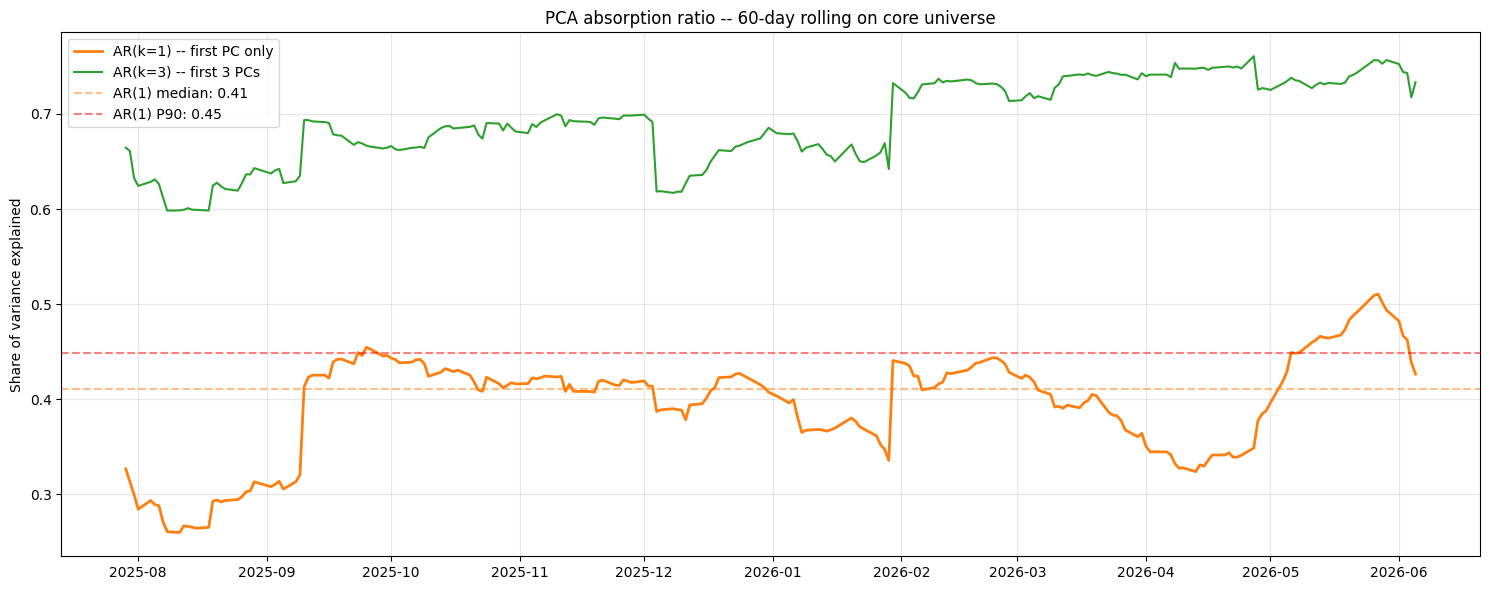


=== Current absorption ratio ===
  AR(k=1) latest: 0.426  (median 0.411, P90 0.449)
  AR(k=3) latest: 0.733  (median 0.691, P90 0.743)
  Z-score AR(1) vs full distribution: +0.58


In [11]:
def absorption_ratio(df: pd.DataFrame, k: int = 1) -> float:
    df = df.dropna(how='any', axis=1)
    if df.shape[1] < 2 or df.shape[0] < df.shape[1]:
        return np.nan
    cov = df.cov().values
    eig = np.linalg.eigvalsh(cov)[::-1]  # descending
    return float(eig[:k].sum() / eig.sum())

def rolling_absorption(df: pd.DataFrame, window: int = 60, k: int = 1) -> pd.Series:
    out, idx = [], []
    for i in range(window, len(df) + 1):
        out.append(absorption_ratio(df.iloc[i-window:i], k=k))
        idx.append(df.index[i-1])
    return pd.Series(out, index=idx)

ar60_k1 = rolling_absorption(core_ret, window=60, k=1)
ar60_k3 = rolling_absorption(core_ret, window=60, k=3)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(ar60_k1.index, ar60_k1.values, lw=2, color='C1', label='AR(k=1) -- first PC only')
ax.plot(ar60_k3.index, ar60_k3.values, lw=1.5, color='C2', label='AR(k=3) -- first 3 PCs')
ax.axhline(ar60_k1.median(), color='C1', linestyle='--', alpha=0.5,
           label=f'AR(1) median: {ar60_k1.median():.2f}')
ax.axhline(ar60_k1.quantile(0.9), color='red', linestyle='--', alpha=0.5,
           label=f'AR(1) P90: {ar60_k1.quantile(0.9):.2f}')
ax.set_title('PCA absorption ratio -- 60-day rolling on core universe', fontsize=12)
ax.set_ylabel('Share of variance explained')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'absorption_ratio.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'\n=== Current absorption ratio ===')
print(f'  AR(k=1) latest: {ar60_k1.iloc[-1]:.3f}  '
      f'(median {ar60_k1.median():.3f}, P90 {ar60_k1.quantile(0.9):.3f})')
print(f'  AR(k=3) latest: {ar60_k3.iloc[-1]:.3f}  '
      f'(median {ar60_k3.median():.3f}, P90 {ar60_k3.quantile(0.9):.3f})')
print(f'  Z-score AR(1) vs full distribution: '
      f'{(ar60_k1.iloc[-1] - ar60_k1.mean()) / ar60_k1.std():+.2f}')
ar60_k1.to_csv(OUT_DIR / 'csv' / 'absorption_ratio_k1.csv')

### 5.3 Cross-sectional return dispersion

Cross-sectional dispersion (std of daily returns across the universe) is a complementary measure: low dispersion + high correlation = lockstep moves = systemic stress.

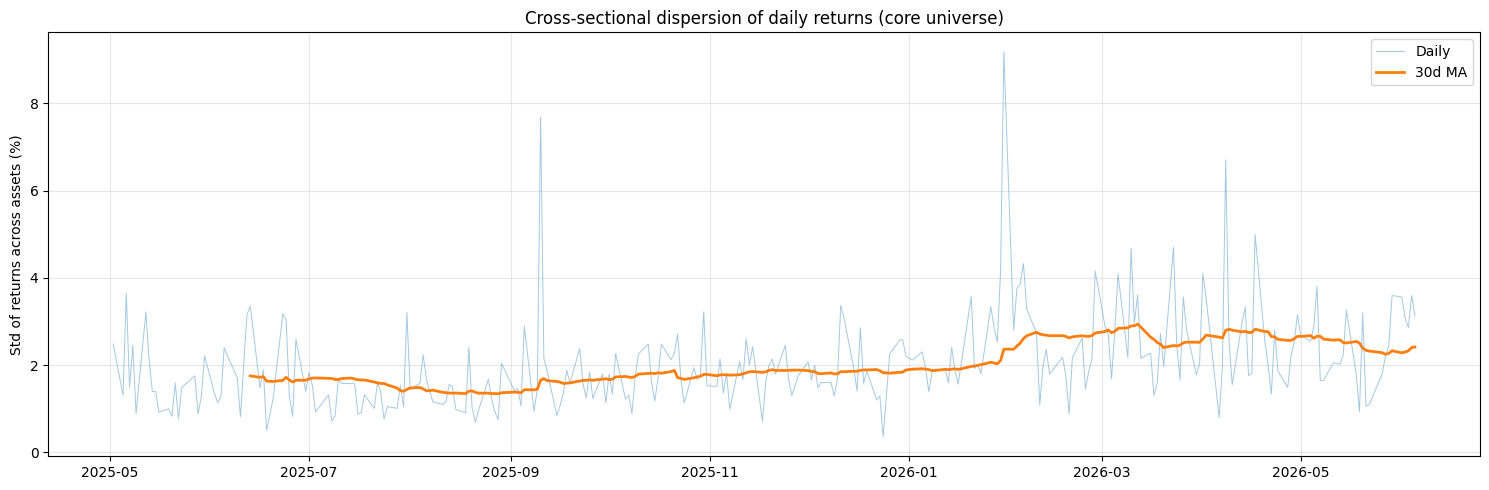

Current daily dispersion: 3.13% (historical median 1.81%, P90 3.25%)


In [12]:
cs_disp = core_ret.std(axis=1)  # per-day cross-sectional std of returns
cs_disp_30d = cs_disp.rolling(30).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(cs_disp.index, cs_disp.values * 100, lw=0.7, color='C0', alpha=0.4, label='Daily')
ax.plot(cs_disp_30d.index, cs_disp_30d.values * 100, lw=2, color='C1', label='30d MA')
ax.set_title('Cross-sectional dispersion of daily returns (core universe)', fontsize=12)
ax.set_ylabel('Std of returns across assets (%)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'cross_sectional_dispersion.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Current daily dispersion: {cs_disp.iloc[-1]*100:.2f}% '
      f'(historical median {cs_disp.median()*100:.2f}%, P90 {cs_disp.quantile(0.9)*100:.2f}%)')

### 5.4 Forbes-Rigobon (2002) volatility-adjusted correlation

Pearson correlation mechanically inflates when one of the underlying volatilities rises -- a feature noted by Forbes & Rigobon (2002), *"No Contagion, Only Interdependence: Measuring Stock Market Comovements"* (*Journal of Finance*). The adjusted correlation is

$$\rho^*_{ij} = \frac{\rho_{ij}}{\sqrt{1 + \delta_i\,(1 - \rho_{ij}^2)}}, \quad
\delta_i = \frac{\sigma_{i,\text{stress}}^2}{\sigma_{i,\text{calm}}^2} - 1$$

We compare the unadjusted 7-day correlation to the adjusted version using the 180-day window as the "calm" reference period.

In [13]:
def forbes_rigobon_adjusted(corr_stress: pd.DataFrame, sigma_stress: pd.Series,
                              sigma_calm: pd.Series) -> pd.DataFrame:
    """Forbes-Rigobon volatility-adjusted correlation matrix."""
    adj = corr_stress.copy()
    for i in adj.index:
        for j in adj.columns:
            if i == j or pd.isna(corr_stress.loc[i, j]):
                continue
            # We adjust for the volatility ratio of the more volatile of i, j
            delta_i = (sigma_stress[i]**2 / sigma_calm[i]**2) - 1
            r = corr_stress.loc[i, j]
            adj.loc[i, j] = r / np.sqrt(1 + delta_i * (1 - r**2))
    return adj

ret_stress = ret.iloc[-7:][common]
ret_calm = ret.iloc[-180:-7][common]
sigma_s = ret_stress.std()
sigma_c = ret_calm.std()

corr_7_p_sub = corr_7_p.loc[common, common]
corr_adj = forbes_rigobon_adjusted(corr_7_p_sub, sigma_s, sigma_c)

# Compare average off-diagonal
def offdiag_mean(m):
    arr = m.values.copy()
    np.fill_diagonal(arr, np.nan)
    return np.nanmean(arr)

print(f'Average pairwise correlation, 7-day window:')
print(f'  Pearson (raw):         {offdiag_mean(corr_7_p_sub):+.3f}')
print(f'  Forbes-Rigobon adj.:   {offdiag_mean(corr_adj):+.3f}')
print(f'  Pearson (180d calm):   {offdiag_mean(corr_180_p.loc[common, common]):+.3f}')
print()
print('Interpretation: if FR-adjusted >> calm baseline, the correlation jump is *real* (not\n'
      'just a volatility artifact). If FR-adjusted ~ calm baseline, vol inflation explains\n'
      'the apparent correlation increase.')

Average pairwise correlation, 7-day window:
  Pearson (raw):         +0.176
  Forbes-Rigobon adj.:   +0.140
  Pearson (180d calm):   +0.133

Interpretation: if FR-adjusted >> calm baseline, the correlation jump is *real* (not
just a volatility artifact). If FR-adjusted ~ calm baseline, vol inflation explains
the apparent correlation increase.


## 6. Flight-to-quality diagnostic (gold vs equities)

In normal regimes, gold and equities exhibit low or negative correlation (gold is a recognized safe-haven). When pairwise corr(XAU, SPX) becomes strongly positive over short windows, this is the empirical fingerprint of margin-call selling -- leveraged funds are forced to liquidate gold positions alongside equities to meet calls.

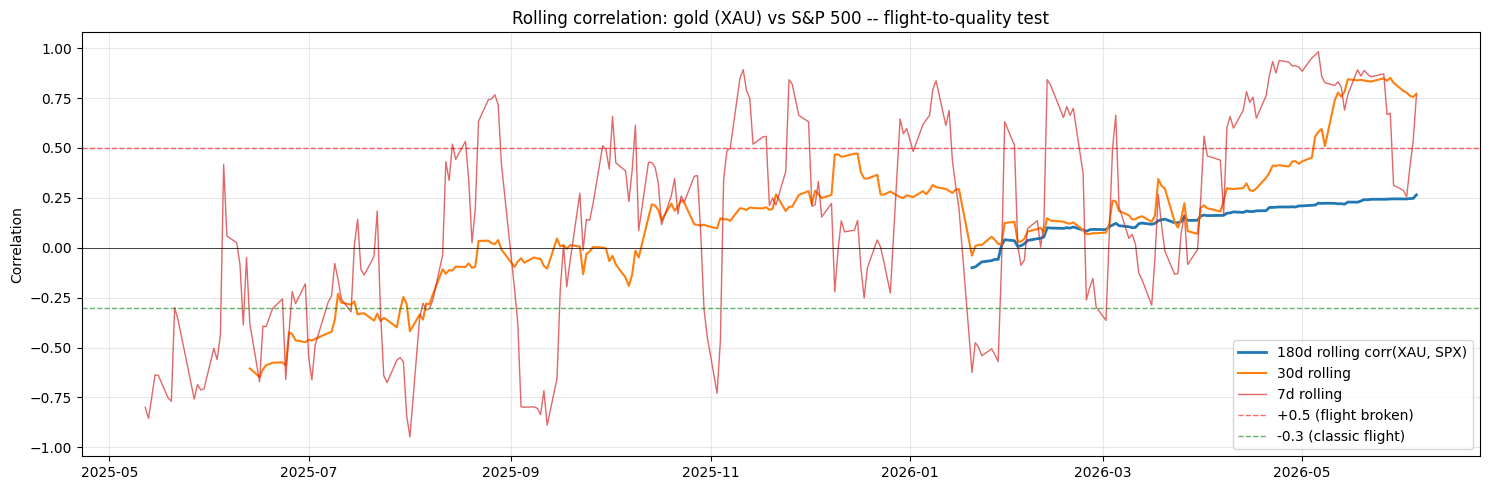


=== XAU vs SPX correlation ===
  Current 7d  : +0.765
  Current 30d : +0.771
  Current 180d: +0.265
  >>> Flight-to-quality regime BROKEN -- gold correlating with equities (margin-call signature)


In [14]:
if 'XAU' in ret.columns and 'SPX' in ret.columns:
    pair = ret[['XAU', 'SPX']].dropna()
    roll_7 = pair['XAU'].rolling(7).corr(pair['SPX'])
    roll_30 = pair['XAU'].rolling(30).corr(pair['SPX'])
    roll_180 = pair['XAU'].rolling(180).corr(pair['SPX'])

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(roll_180.index, roll_180.values, lw=2, color='C0', label='180d rolling corr(XAU, SPX)')
    ax.plot(roll_30.index, roll_30.values, lw=1.5, color='C1', label='30d rolling')
    ax.plot(roll_7.index, roll_7.values, lw=1, color='C3', alpha=0.7, label='7d rolling')
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.6, label='+0.5 (flight broken)')
    ax.axhline(-0.3, color='green', linestyle='--', lw=1, alpha=0.6, label='-0.3 (classic flight)')
    ax.set_title('Rolling correlation: gold (XAU) vs S&P 500 -- flight-to-quality test', fontsize=12)
    ax.set_ylabel('Correlation')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'plots' / 'flight_to_quality.png', dpi=110, bbox_inches='tight')
    plt.show()

    print(f'\n=== XAU vs SPX correlation ===')
    print(f'  Current 7d  : {roll_7.iloc[-1]:+.3f}')
    print(f'  Current 30d : {roll_30.iloc[-1]:+.3f}')
    print(f'  Current 180d: {roll_180.iloc[-1]:+.3f}')
    if roll_7.iloc[-1] > 0.5:
        print('  >>> Flight-to-quality regime BROKEN -- gold correlating with equities (margin-call signature)')
    elif roll_7.iloc[-1] < -0.3:
        print('  >>> Classic flight-to-quality (gold up, equities down)')
    else:
        print('  >>> XAU decoupled from equities (normal weak correlation)')

## 7. Volatility regime (VIX) and dollar

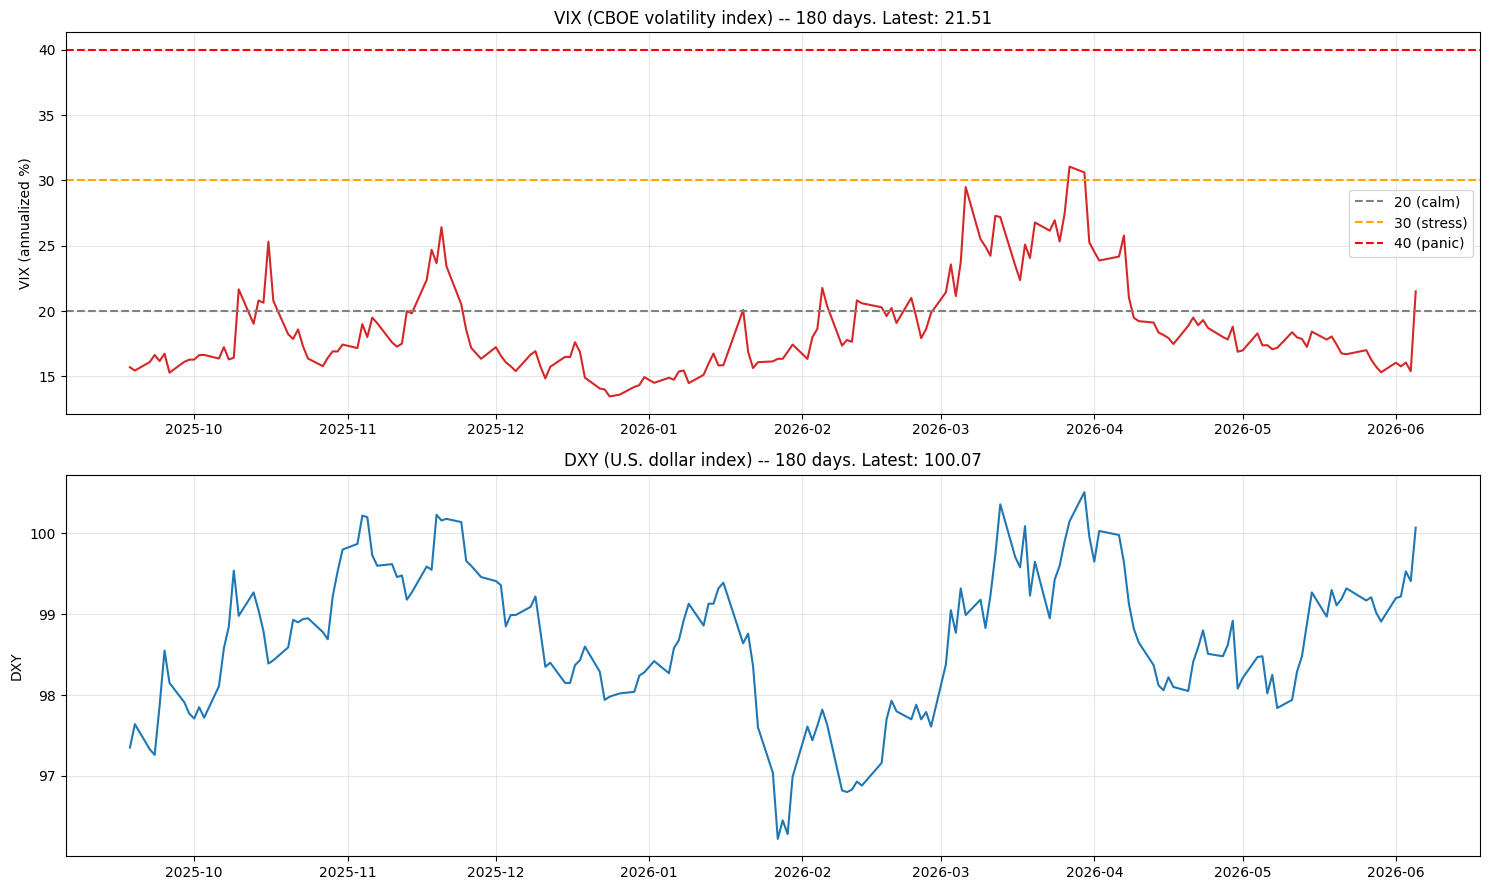

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
if 'VIX' in px_eq.columns:
    vix = px_eq['VIX'].iloc[-180:].dropna()
    axes[0].plot(vix.index, vix.values, color='C3', lw=1.5)
    axes[0].axhline(20, color='gray', linestyle='--', label='20 (calm)')
    axes[0].axhline(30, color='orange', linestyle='--', label='30 (stress)')
    axes[0].axhline(40, color='red', linestyle='--', label='40 (panic)')
    axes[0].set_title(f'VIX (CBOE volatility index) -- 180 days. Latest: {vix.iloc[-1]:.2f}', fontsize=12)
    axes[0].legend()
    axes[0].set_ylabel('VIX (annualized %)')
if 'DXY' in px_eq.columns:
    dxy = px_eq['DXY'].iloc[-180:].dropna()
    axes[1].plot(dxy.index, dxy.values, color='C0', lw=1.5)
    axes[1].set_title(f'DXY (U.S. dollar index) -- 180 days. Latest: {dxy.iloc[-1]:.2f}', fontsize=12)
    axes[1].set_ylabel('DXY')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'vix_dxy.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Burry-disclosed short candidates -- realized stock returns since 2025 Q3 13F

Scion Asset Management's Q3 2025 13F filing (as of September 30, 2025) disclosed put positions of about \$912M notional on Palantir and \$187M notional on Nvidia. Subsequent 2026 commentary expanded the bearish thesis to ORCL, SMH (semiconductor ETF) and QQQ (Nasdaq 100 trust) with January 2027 expiries.

We compute the **realized stock-side** return from the 13F snapshot date. A negative stock return implies a profitable put-side P&L (subject to time decay and IV changes -- not modeled here).

=== Burry-disclosed shorts -- stock-side returns since 2025-09-30 ===
     entry_price latest_price stock_return_pct put_side_inference
PLTR  182.419998   135.529999       -25.704418         profitable
NVDA  186.342331   205.100006        10.066245         underwater
SMH   325.347626   569.690002        75.101939         underwater
QQQ   598.842407   705.059998        17.737152         underwater
ORCL  279.038025   213.679993       -23.422626         profitable


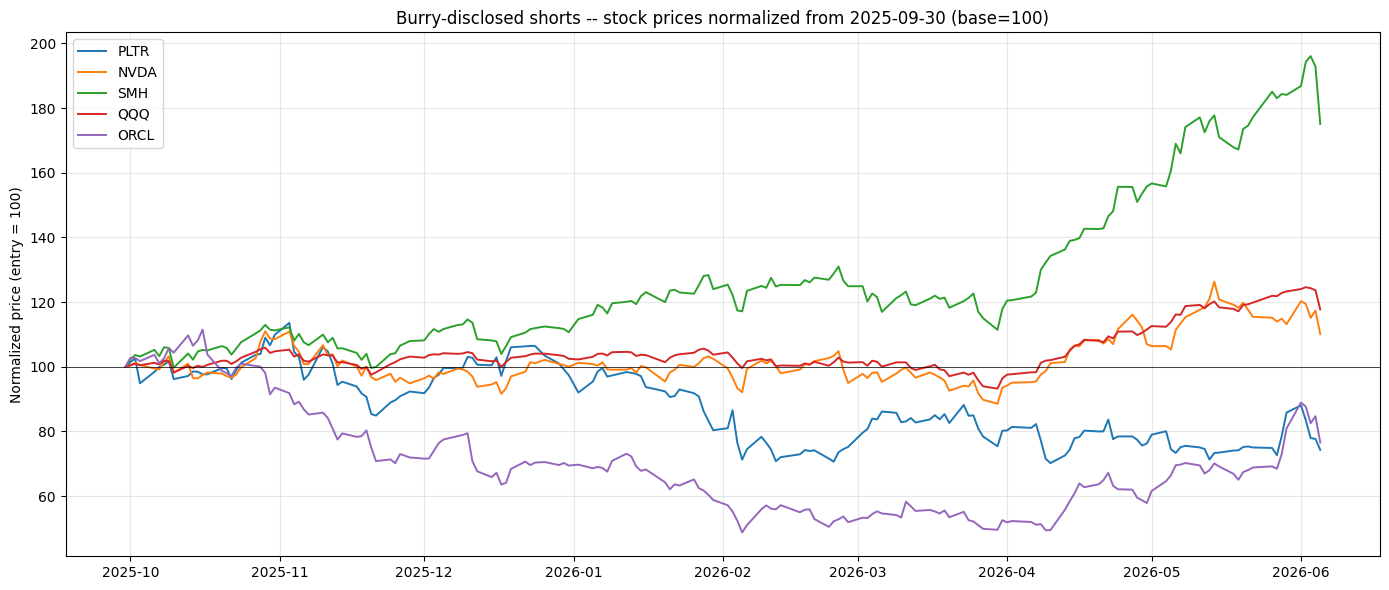

In [16]:
ENTRY = '2025-09-30'  # Burry's 13F filing date
burry_perf = {}
for tk in BURRY_SHORTS:
    if tk not in px_eq.columns:
        continue
    s = px_eq[tk].dropna()
    s_post = s[s.index >= ENTRY]
    if len(s_post) < 2:
        continue
    pct = (s_post.iloc[-1] / s_post.iloc[0] - 1) * 100
    burry_perf[tk] = {'entry_price': float(s_post.iloc[0]),
                       'latest_price': float(s_post.iloc[-1]),
                       'stock_return_pct': float(pct),
                       'put_side_inference': 'profitable' if pct < 0 else 'underwater'}

burry_df = pd.DataFrame(burry_perf).T
print(f'=== Burry-disclosed shorts -- stock-side returns since {ENTRY} ===')
print(burry_df.to_string())
burry_df.to_csv(OUT_DIR / 'csv' / 'burry_shorts_perf.csv')

# Plot normalized
available = [t for t in BURRY_SHORTS if t in px_eq.columns]
burry_panel = px_eq[available].loc[ENTRY:].dropna()
normalized = burry_panel.divide(burry_panel.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for c in normalized.columns:
    ax.plot(normalized.index, normalized[c], label=c, lw=1.4)
ax.axhline(100, color='black', lw=0.5)
ax.set_title(f'Burry-disclosed shorts -- stock prices normalized from {ENTRY} (base=100)', fontsize=12)
ax.set_ylabel('Normalized price (entry = 100)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'burry_shorts.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Composite scorecard -- crisis-signature checks

We aggregate five independent diagnostics into a 0--5 crisis scorecard. Each check is binary ("signal firing" or "not yet"); the scorecard is meant as a *heuristic synthesis*, not a probability estimate.

In [17]:
checks: list[tuple[str, bool, str]] = []

# 1. Avg pairwise correlation 7d > P90 of 30d distribution
p90_30 = stress_30d.quantile(0.9)
fired = bool(stress_7d.iloc[-1] > p90_30)
checks.append(('Stress index 7d > P90(30d hist)', fired,
               f'7d={stress_7d.iloc[-1]:+.3f}  P90={p90_30:+.3f}'))

# 2. XAU-SPX 7d corr > +0.5
if 'XAU' in ret.columns and 'SPX' in ret.columns:
    pair = ret[['XAU', 'SPX']].dropna()
    r7 = pair['XAU'].rolling(7).corr(pair['SPX']).iloc[-1]
    fired = bool(r7 > 0.5)
    checks.append(('XAU-SPX 7d corr > +0.5 (flight broken)', fired,
                    f'corr={r7:+.3f}'))

# 3. Tech 30d max-drawdown < -10% on average
tech_dds = []
for c in ['NVDA', 'AVGO', 'PLTR', 'MSFT', 'NDX', 'SMH']:
    if c in px_eq.columns:
        s = px_eq[c].iloc[-30:].dropna()
        if len(s) >= 5:
            tech_dds.append((s.iloc[-1] / s.max() - 1) * 100)
if tech_dds:
    avg_dd = float(np.mean(tech_dds))
    fired = avg_dd < -10
    checks.append((f'Avg tech max-DD from 30d peak < -10%', fired,
                    f'avg_dd={avg_dd:.1f}%'))

# 4. VIX > 30 OR VIX 7d return > 50%
if 'VIX' in px_eq.columns:
    vix_lvl = float(px_eq['VIX'].iloc[-1])
    vix_7d = float((px_eq['VIX'].iloc[-1] / px_eq['VIX'].iloc[-7] - 1) * 100)
    fired = vix_lvl > 30 or vix_7d > 50
    checks.append(('VIX > 30 or VIX 7d return > +50%', fired,
                    f'VIX={vix_lvl:.1f}  7d={vix_7d:+.1f}%'))

# 5. Metals down (XAU 7d < -3% AND XAG 7d < -3%)
metals_fired = False
details = ''
if 'XAU' in px_eq.columns and 'XAG' in px_eq.columns:
    xau_7 = float((px_eq['XAU'].iloc[-1] / px_eq['XAU'].iloc[-7] - 1) * 100)
    xag_7 = float((px_eq['XAG'].iloc[-1] / px_eq['XAG'].iloc[-7] - 1) * 100)
    metals_fired = (xau_7 < -3) and (xag_7 < -3)
    details = f'XAU 7d={xau_7:+.1f}%  XAG 7d={xag_7:+.1f}%'
    checks.append(('Both metals 7d < -3%', metals_fired, details))

# 6. Absorption ratio AR(1) above its P90
p90_ar = ar60_k1.quantile(0.9)
fired_ar = bool(ar60_k1.iloc[-1] > p90_ar)
checks.append((f'PCA absorption ratio AR(1) > P90 hist',
                fired_ar,
                f'AR(1)={ar60_k1.iloc[-1]:.3f}  P90={p90_ar:.3f}'))

# Report
print('=' * 78)
print(f'CRISIS-SIGNATURE SCORECARD -- {ANALYSIS_DATE}')
print('=' * 78)
fired_count = sum(1 for _, f, _ in checks if f)
for name, fired, details in checks:
    mark = '[X]' if fired else '[ ]'
    print(f'  {mark} {name}\n        {details}')

print(f'\n>>> Score: {fired_count} / {len(checks)} signals firing <<<')
if fired_count >= 5:
    print('    -> RED: multiple simultaneous crisis signatures.')
elif fired_count >= 3:
    print('    -> ORANGE: elevated-risk regime, several diagnostics tripping.')
elif fired_count >= 1:
    print('    -> YELLOW: isolated signal(s), watch for escalation.')
else:
    print('    -> GREEN: no acute stress signature.')

# Persist scorecard JSON
scorecard_out = {
    'analysis_date': ANALYSIS_DATE,
    'checks': [{'name': n, 'fired': f, 'details': d} for n, f, d in checks],
    'score': fired_count,
    'max_score': len(checks),
}
with open(OUT_DIR / 'scorecard.json', 'w') as f:
    json.dump(scorecard_out, f, indent=2)
print(f'\nSaved: {OUT_DIR / "scorecard.json"}')

CRISIS-SIGNATURE SCORECARD -- 2026-06-05
  [ ] Stress index 7d > P90(30d hist)
        7d=+0.295  P90=+0.314
  [X] XAU-SPX 7d corr > +0.5 (flight broken)
        corr=+0.765
  [X] Avg tech max-DD from 30d peak < -10%
        avg_dd=-12.4%
  [ ] VIX > 30 or VIX 7d return > +50%
        VIX=21.5  7d=+36.7%
  [X] Both metals 7d < -3%
        XAU 7d=-3.2%  XAG 7d=-10.1%
  [ ] PCA absorption ratio AR(1) > P90 hist
        AR(1)=0.426  P90=0.449

>>> Score: 3 / 6 signals firing <<<
    -> ORANGE: elevated-risk regime, several diagnostics tripping.

Saved: data\scorecard.json


## 10. Summary and limitations

**Key observations** (auto-generated from the cells above):
- Performance distribution on the analysis day, ranked from worst to best 1-day return
- Whether the gold-equities correlation has flipped to positive territory (flight-to-quality test)
- Whether the rolling avg pairwise correlation has breached its historical P90
- Whether the PCA absorption ratio is in the upper tail of its historical distribution
- VIX level and 7-day acceleration
- Realized stock-side P&L on the Burry-disclosed shorts since the Q3 2025 13F

**Limitations and caveats**

1. **No options-side P&L modeling.** The Burry put positions have time decay and IV exposure -- the stock-side return is only the directional component. A 13F discloses notional, not realized P&L.
2. **Forbes-Rigobon adjustment** assumes the within-window volatility regime is well-estimated; with only 7 daily observations the adjusted estimate has wide variance.
3. **i.i.d. bootstrap CIs** for the stress index are conservative *only* if returns are weakly dependent. Under serial autocorrelation, true CIs are wider (block bootstrap would be appropriate).
4. **Futures rolls** (`GC=F`, `SI=F`, `CL=F`, `BZ=F`) introduce small discontinuities; for the purpose of stress diagnostics over short windows this is acceptable but for long-horizon performance attribution one should switch to back-adjusted continuous contracts.
5. **Yahoo data is end-of-day** -- intra-day stress signals (e.g. flash crashes) are not captured.
6. **Survivorship bias is absent** for indices and large-caps over this short window but the cross-asset panel was selected based on contemporary public discussion (Burry shorts), not a pre-registered universe -- selection bias should be acknowledged.
7. **Crypto observations on weekends** are folded into the next U.S. trading day for the joint panel; this is a methodological choice, alternative alignments are possible.

**This notebook is a diagnostic tool, not a forecast.** Burry himself notes (per his May 10, 2026 Substack note) that he has been wrong on prior crash calls. The scorecard records the *configuration* of contemporaneous signals; the implied probability of a continuation crash is *not* inferable from this configuration alone without additional macro and policy context.

## References

- Forbes, K. J. & Rigobon, R. (2002). *No Contagion, Only Interdependence: Measuring Stock Market Comovements*. Journal of Finance, 57(5).
- Kritzman, M., Li, Y., Page, S., & Rigobon, R. (2010). *Principal Components as a Measure of Systemic Risk*. Journal of Portfolio Management.
- Pukthuanthong, K. & Roll, R. (2009). *Global Market Integration: An Alternative Measure and Its Application*. Journal of Financial Economics.
- Burry, M. (2026, May 10). *Short Thoughts*. michaeljburry.substack.com.
- Bloomberg (2026, May 11). *Michael Burry Warns of Stock Crash as Tech Jump Echoes 2000 Peak*.
- Scion Asset Management 13F-HR filing as of September 30, 2025 (SEC EDGAR).
- Kabbaj, T. (2026, June 5). *Vendredi noir : tout s'effondre en Bourse?*. YouTube (TKL channel). https://www.youtube.com/watch?v=JqFg1Oup11k


## 11. Data export -- for republication

In [18]:
# Export full close-price panel and log-return panel as CSV for reproducibility
px_eq.to_csv(OUT_DIR / 'csv' / 'close_prices_panel.csv')
ret.to_csv(OUT_DIR / 'csv' / 'log_returns_panel.csv')

# Manifest with the configuration used
manifest = {
    'analysis_date': ANALYSIS_DATE,
    'data_source': 'Yahoo Finance via yfinance (auto_adjust=True)',
    'lookback_days': LOOKBACK_DAYS,
    'fetched_at': datetime.now().isoformat(),
    'tickers': TICKERS,
    'asset_groups': {
        'equities': EQUITIES,
        'metals': METALS,
        'energy': ENERGY,
        'crypto': CRYPTO,
        'bonds': BONDS,
        'dollar_vol': DOLLAR_VOL,
        'burry_shorts': BURRY_SHORTS,
    },
    'core_universe': CORE,
    'n_observations': len(px_eq),
    'first_date': px_eq.index[0].isoformat(),
    'last_date': px_eq.index[-1].isoformat(),
}
with open(OUT_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print('=== Export complete ===')
print(f'Output directory: {OUT_DIR.resolve()}')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f'  {p.relative_to(OUT_DIR)}  ({size_kb:.1f} KB)')

=== Export complete ===
Output directory: D:\dev\projects\labs\202606\data
  csv\AAPL.csv  (25.6 KB)
  csv\absorption_ratio_k1.csv  (6.6 KB)
  csv\AVGO.csv  (25.2 KB)
  csv\BRENT.csv  (23.7 KB)
  csv\BTC.csv  (30.6 KB)
  csv\burry_shorts_perf.csv  (0.4 KB)
  csv\close_prices_panel.csv  (100.2 KB)
  csv\DJI.csv  (21.0 KB)
  csv\DXY.csv  (22.7 KB)
  csv\log_returns_panel.csv  (124.0 KB)
  csv\META.csv  (24.3 KB)
  csv\MSFT.csv  (25.3 KB)
  csv\NDX.csv  (22.4 KB)
  csv\NFLX.csv  (24.7 KB)
  csv\NVDA.csv  (26.0 KB)
  csv\ORCL.csv  (25.5 KB)
  csv\performance_snapshot.csv  (4.7 KB)
  csv\PLTR.csv  (25.0 KB)
  csv\QQQ.csv  (24.7 KB)
  csv\SMH.csv  (24.7 KB)
  csv\SPX.csv  (23.2 KB)
  csv\stress_index_30d.csv  (7.6 KB)
  csv\stress_index_7d.csv  (8.3 KB)
  csv\TLT.csv  (24.9 KB)
  csv\VIX.csv  (23.5 KB)
  csv\WTI.csv  (23.9 KB)
  csv\XAG.csv  (23.2 KB)
  csv\XAU.csv  (19.7 KB)
  manifest.json  (1.5 KB)
  plots\absorption_ratio.png  (96.5 KB)
  plots\burry_shorts.png  (148.9 KB)
  plots\correl